# 1. Installs & Imports

In [1]:
!pip install transformers scikit-learn pandas matplotlib seaborn tqdm

import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW  # <-- FIXED IMPORT
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import re

# Set device to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# 2. Data Preprocessing & Splitting

In [3]:
# 1. Load the dataset (Make sure 'IMDB Dataset.csv' is uploaded to Colab!)
df = pd.read_csv('IMDB Dataset.csv')

# 2. Clean the text (Remove HTML <br> tags)
def clean_text(text):
    text = re.sub(r'<br\s*/?>', ' ', text)
    return text

df['review'] = df['review'].apply(clean_text)

# 3. Map string labels to integers (0 = negative, 1 = positive)
df['sentiment'] = df['sentiment'].map({'negative': 0, 'positive': 1})

# Handle any missing values
df = df.dropna()

# 4. Data Splitting (80% Train, 10% Val, 10% Test)
# First split: 90% Temp (Train+Val) and 10% Test
X_temp, X_test, y_temp, y_test = train_test_split(df['review'], df['sentiment'], test_size=0.1, random_state=42)

# Second split: Split the 90% Temp into Train (80% overall) and Val (10% overall)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1111, random_state=42)

print(f"Train size: {len(X_train)}, Val size: {len(X_val)}, Test size: {len(X_test)}")

Train size: 40000, Val size: 5000, Test size: 5000


# 3. Tokenization & Custom Dataset Class

In [4]:
# Initialize Tokenizer
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

# Define the PyTorch Dataset Class
class IMDBDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128): # max_length 128 for faster training
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Create Dataset Objects
train_dataset = IMDBDataset(X_train, y_train, tokenizer)
val_dataset = IMDBDataset(X_val, y_val, tokenizer)
test_dataset = IMDBDataset(X_test, y_test, tokenizer)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# 4. The Universal Training Function

In [5]:
def train_model(model, dataloader, optimizer, epochs=2): # 2 Epochs to save time before deadline
    model.train()

    for epoch in range(epochs):
        total_loss = 0
        print(f"\nEpoch {epoch+1}/{epochs}")

        for batch in tqdm(dataloader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        print(f"Average Training Loss: {avg_loss:.4f}")

    return model

# 5. Experiment 1 (Frozen Base Layers)

In [6]:
print("Initializing Experiment 1: Frozen BERT...")
model_1 = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to(device)

# Freeze base layers
for param in model_1.bert.parameters():
    param.requires_grad = False

optimizer_1 = AdamW(model_1.parameters(), lr=2e-5)

print("Training Experiment 1...")
trained_model_1 = train_model(model_1, train_loader, optimizer_1, epochs=2)

Initializing Experiment 1: Frozen BERT...


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training Experiment 1...

Epoch 1/2


100%|██████████| 2500/2500 [06:00<00:00,  6.94it/s]


Average Training Loss: 0.6813

Epoch 2/2


100%|██████████| 2500/2500 [06:03<00:00,  6.88it/s]

Average Training Loss: 0.6560


# 6. Experiment 2 (Unfreeze Last 2 Layers)

In [7]:
print("Initializing Experiment 2: Unfrozen Last 2 Layers...")
model_2 = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to(device)

# Freeze base layers first
for param in model_2.bert.parameters():
    param.requires_grad = False

# Unfreeze the last 2 layers
for param in model_2.bert.encoder.layer[-2:].parameters():
    param.requires_grad = True

optimizer_2 = AdamW(model_2.parameters(), lr=2e-5)

print("Training Experiment 2...")
trained_model_2 = train_model(model_2, train_loader, optimizer_2, epochs=2)

Initializing Experiment 2: Unfrozen Last 2 Layers...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training Experiment 2...

Epoch 1/2


100%|██████████| 2500/2500 [07:51<00:00,  5.30it/s]


Average Training Loss: 0.3508

Epoch 2/2


100%|██████████| 2500/2500 [07:53<00:00,  5.28it/s]

Average Training Loss: 0.2879


# 7. Evaluation Function

In [8]:
def evaluate_model(model, dataloader):
    model.eval()
    predictions, true_labels = [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1).cpu().numpy()

            predictions.extend(preds)
            true_labels.extend(labels.cpu().numpy())

    return true_labels, predictions

# 8. Results & Confusion Matrices


--- Experiment 1 (Frozen) Metrics ---


Evaluating: 100%|██████████| 313/313 [00:51<00:00,  6.12it/s]


              precision    recall  f1-score   support

    Negative       0.70      0.60      0.65      2481
    Positive       0.66      0.75      0.70      2519

    accuracy                           0.68      5000
   macro avg       0.68      0.67      0.67      5000
weighted avg       0.68      0.68      0.67      5000


--- Experiment 2 (Unfrozen Last 2 Layers) Metrics ---


Evaluating: 100%|██████████| 313/313 [00:44<00:00,  7.06it/s]


              precision    recall  f1-score   support

    Negative       0.89      0.88      0.88      2481
    Positive       0.88      0.89      0.89      2519

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



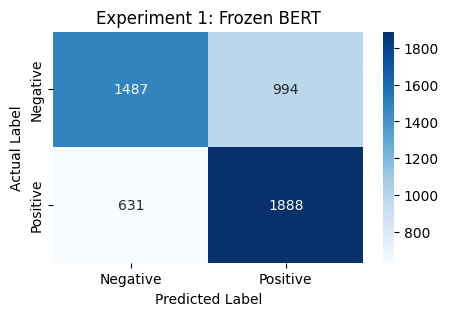

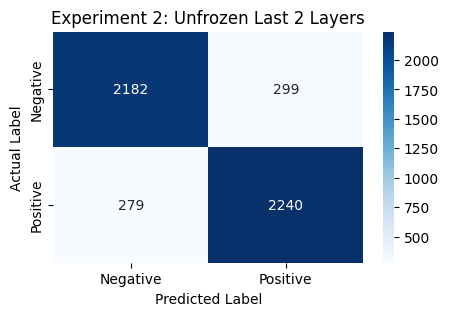

In [9]:
# Evaluate Model 1
print("\n--- Experiment 1 (Frozen) Metrics ---")
true_1, preds_1 = evaluate_model(trained_model_1, test_loader)
print(classification_report(true_1, preds_1, target_names=['Negative', 'Positive']))

# Evaluate Model 2
print("\n--- Experiment 2 (Unfrozen Last 2 Layers) Metrics ---")
true_2, preds_2 = evaluate_model(trained_model_2, test_loader)
print(classification_report(true_2, preds_2, target_names=['Negative', 'Positive']))

# Plotting Function
def plot_confusion_matrix(true_labels, predictions, title):
    cm = confusion_matrix(true_labels, predictions)
    plt.figure(figsize=(5, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.title(title)
    plt.show()

# Generate Plots
plot_confusion_matrix(true_1, preds_1, "Experiment 1: Frozen BERT")
plot_confusion_matrix(true_2, preds_2, "Experiment 2: Unfrozen Last 2 Layers")

# Bonus (Optional)

# B1. The Upgraded Training Loop & Scheduler Imports

In [10]:
from transformers import get_linear_schedule_with_warmup
import copy

def train_model_bonus(model, train_dataloader, val_dataloader, optimizer, scheduler, epochs=3, patience=1):
    best_val_loss = float('inf')
    epochs_no_improve = 0
    # Save the best weights in case the model starts getting worse (overfitting)
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        print(f"\n--- Epoch {epoch+1}/{epochs} (Bonus Run) ---")

        # 1. TRAINING PHASE
        model.train()
        total_train_loss = 0
        for batch in tqdm(train_dataloader, desc="Training"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()

            optimizer.step()
            scheduler.step() # <-- BONUS: Update learning rate scheduler

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_dataloader)

        # 2. VALIDATION PHASE (For Early Stopping)
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for batch in val_dataloader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
                total_val_loss += outputs.loss.item()

        avg_val_loss = total_val_loss / len(val_dataloader)
        print(f"Train Loss: {avg_train_loss:.4f} | Validation Loss: {avg_val_loss:.4f}")

        # 3. EARLY STOPPING LOGIC
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            best_model_wts = copy.deepcopy(model.state_dict()) # Save new best weights
        else:
            epochs_no_improve += 1
            print(f"EarlyStopping counter: {epochs_no_improve} out of {patience}")
            if epochs_no_improve >= patience:
                print("Early stopping triggered! Restoring best model weights.")
                break

    # Load the best weights before returning
    model.load_state_dict(best_model_wts)
    return model

# B2. Setup DistilBERT and Train

In [11]:
print("Initializing Bonus Experiment: DistilBERT...")

# 1. BONUS: Use DistilBERT (Model & Tokenizer)
distil_tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
bonus_model = AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2).to(device)

# Re-create DataLoaders with the DistilBERT tokenizer so the tokens match perfectly
train_dataset_bonus = IMDBDataset(X_train, y_train, distil_tokenizer)
val_dataset_bonus = IMDBDataset(X_val, y_val, distil_tokenizer)
test_dataset_bonus = IMDBDataset(X_test, y_test, distil_tokenizer)

train_loader_bonus = DataLoader(train_dataset_bonus, batch_size=16, shuffle=True)
val_loader_bonus = DataLoader(val_dataset_bonus, batch_size=16, shuffle=False)
test_loader_bonus = DataLoader(test_dataset_bonus, batch_size=16, shuffle=False)

# Optimizer
bonus_optimizer = AdamW(bonus_model.parameters(), lr=2e-5)

# 2. BONUS: Learning Rate Scheduler Setup
epochs = 3
total_steps = len(train_loader_bonus) * epochs
scheduler = get_linear_schedule_with_warmup(
    bonus_optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

# 3. BONUS: Train with Early Stopping
print("Training DistilBERT with Scheduler and Early Stopping...")
trained_bonus_model = train_model_bonus(
    bonus_model,
    train_loader_bonus,
    val_loader_bonus,
    bonus_optimizer,
    scheduler,
    epochs=epochs,
    patience=1 # Stops if validation loss gets worse for 1 epoch
)

Initializing Bonus Experiment: DistilBERT...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Train Loss: 0.3206 | Validation Loss: 0.2862

--- Epoch 2/3 (Bonus Run) ---


Training: 100%|██████████| 2500/2500 [09:07<00:00,  4.57it/s]


Train Loss: 0.1931 | Validation Loss: 0.2611

--- Epoch 3/3 (Bonus Run) ---


Training: 100%|██████████| 2500/2500 [08:59<00:00,  4.63it/s]


Train Loss: 0.1024 | Validation Loss: 0.3165
EarlyStopping counter: 1 out of 1
Early stopping triggered! Restoring best model weights.


# B3. Evaluate the Bonus Model


--- Bonus Experiment (DistilBERT) Metrics ---


Evaluating: 100%|██████████| 313/313 [00:25<00:00, 12.35it/s]


              precision    recall  f1-score   support

    Negative       0.90      0.89      0.90      2481
    Positive       0.89      0.91      0.90      2519

    accuracy                           0.90      5000
   macro avg       0.90      0.90      0.90      5000
weighted avg       0.90      0.90      0.90      5000



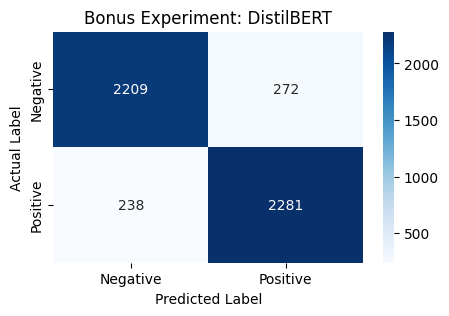

In [12]:
# Evaluate Bonus Model
print("\n--- Bonus Experiment (DistilBERT) Metrics ---")
# Make sure to use the bonus test loader here!
true_bonus, preds_bonus = evaluate_model(trained_bonus_model, test_loader_bonus)

print(classification_report(true_bonus, preds_bonus, target_names=['Negative', 'Positive']))
plot_confusion_matrix(true_bonus, preds_bonus, "Bonus Experiment: DistilBERT")